In [32]:
import sys
print(sys.executable)
import pycaret
print("pycaret version:", pycaret.__version__)
import scipy, sklearn, scikitplot, pycaret
print("scipy     :", scipy.__version__)
print("sklearn   :", sklearn.__version__)
print("scikitplot:", scikitplot.__version__)
print("pycaret   :", pycaret.__version__)

c:\ProgramData\anaconda3\envs\mercari_pycaret\python.exe
pycaret version: 3.2.0
scipy     : 1.10.1
sklearn   : 1.2.2
scikitplot: 0.3.7
pycaret   : 3.2.0


In [33]:
import pycaret
print("pycaret version:", pycaret.__version__)

from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    tune_model as pc_tune_model,
    plot_model,
    predict_model,
)
print("regression import OK")

pycaret version: 3.2.0
regression import OK


In [34]:
import importlib
import kjh_mercari_analyzer as mpc
importlib.reload(mpc)

analyzer = mpc.MercariPyCaretAnalyzer(
    data_dir="../data",
    images_dir="../images",
    results_dir="../results",
    model_dir="../models",
    use_gpu=True,
)


🔍 GPU 가용성 체크 중...
✅ XGBoost 버전: 3.1.2
✅ LightGBM 버전: 4.6.0
✅ CatBoost 버전: 1.2.7
⚠️  GPU를 찾을 수 없습니다. CPU 모드로 전환합니다.


In [35]:
# 2) 전처리 (스테이징 + 캐시 사용)
analyzer.preprocess_all_staged(
    use_cache=True,
    save_cache=True,
    cols=["name", "item_description"],
    undersample_frac=0.30,
    param_dict={"undersample_frac": 0.30},
    debug=True
)

📂 데이터 로딩 시작...
original data shape : train (1482535, 8), test (693359, 7)
✅ Price 외 결측치 처리 및 데이터 전처리 시작...

✅ 데이터 로드 완료: train (1481661, 11), test (693359, 10)

🎯 Undersampling 시작... (method=random)
   원본 크기: 1,481,661
   목표 크기: 444,498
✅ Undersampling 완료: 최종 크기 444,498
💾 전처리 결과 캐시 저장 완료: ../data\train_preprocessed.pkl, ../data\test_preprocessed.pkl

[preprocess_all_staged] 요약
 - 사용 컬럼(cols): ['name', 'item_description']
 - param_dict    : {'undersample_frac': 0.3}
 - train shape   : (444498, 11)
 - test  shape   : (693359, 10)


In [36]:
# 3) 벡터화 (예: FastText)
analyzer.vectorize_text(method="fasttext")

⚠️  method='fasttext' → 현재는 TF-IDF 기반 벡터화로 대체합니다.
📝 텍스트 벡터화 및 차원 축소 시작... (method=fasttext)


Text columns:   0%|          | 0/2 [00:00<?, ?it/s]

▶ 컬럼: name


Text columns:  50%|█████     | 1/2 [00:27<00:27, 27.90s/it]

   ▪ 차원 축소 완료: 100 components
▶ 컬럼: item_description


Text columns: 100%|██████████| 2/2 [01:38<00:00, 49.11s/it]

   ▪ 차원 축소 완료: 100 components


✅ 벡터화 + 차원 축소 + 카테고리 인코딩 완료: train (444498, 205), test (693359, 205)


In [37]:
# 4) PyCaret setup
analyzer.setup_pycaret(fold=3, use_gpu=False, n_jobs=4)

🔧 PyCaret setup 시작...


,Description,Value
0,Session id,23
1,Target,price
2,Target type,Regression
3,Original data shape,"(444498, 206)"
4,Transformed data shape,"(444498, 216)"
5,Transformed train set shape,"(311148, 216)"
6,Transformed test set shape,"(133350, 216)"
7,Ordinal features,1
8,Numeric features,200
9,Categorical features,5


✅ PyCaret setup 완료


In [38]:
# 5) 베스트 모델 찾기 (Kaggle RMSLE 기준)
best_model = analyzer.find_best_model()


🔍 후보 모델 RMSLE(log1p) 비교:

▶ lightgbm 모델 생성/평가...


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4416,0.3309,0.5752,0.4034,0.1427,0.1570
1,0.4425,0.3320,0.5762,0.4005,0.1432,0.1578
2,0.4419,0.3332,0.5772,0.4027,0.1430,0.1570
Mean,0.4420,0.3320,0.5762,0.4022,0.1430,0.1573
Std,0.0004,0.0009,0.0008,0.0013,0.0002,0.0004


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.4416  0.3309  0.5752  0.4034  0.1427  0.1570
1     0.4425  0.3320  0.5762  0.4005  0.1432  0.1578
2     0.4419  0.3332  0.5772  0.4027  0.1430  0.1570
Mean  0.4420  0.3320  0.5762  0.4022  0.1430  0.1573
Std   0.0004  0.0009  0.0008  0.0013  0.0002  0.0004



▶ xgboost 모델 생성/평가...


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4276,0.3133,0.5597,0.4351,0.1388,0.1515
1,0.4287,0.3149,0.5611,0.4313,0.1394,0.1523
2,0.4285,0.3158,0.5620,0.4339,0.1394,0.1517
Mean,0.4283,0.3147,0.5610,0.4334,0.1392,0.1518
Std,0.0005,0.0010,0.0009,0.0016,0.0003,0.0004


...

         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.4239  0.3126  0.5591  0.4364  0.1385  0.1509
1     0.4237  0.3131  0.5595  0.4346  0.1389  0.1513
2     0.4244  0.3149  0.5612  0.4355  0.1390  0.1510
Mean  0.4240  0.3135  0.5599  0.4355  0.1388  0.1511
Std   0.0003  0.0010  0.0009  0.0007  0.0002  0.0002



▶ rf 모델 생성/평가...


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4392,0.3319,0.5761,0.4016,0.1430,0.1568
1,0.4395,0.3333,0.5773,0.3980,0.1435,0.1574
2,0.4386,0.3337,0.5777,0.4018,0.1432,0.1564
Mean,0.4391,0.3330,0.5770,0.4005,0.1432,0.1569
Std,0.0004,0.0008,0.0007,0.0017,0.0002,0.0004


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.4392  0.3319  0.5761  0.4016  0.1430  0.1568
1     0.4395  0.3333  0.5773  0.3980  0.1435  0.1574
2     0.4386  0.3337  0.5777  0.4018  0.1432  0.1564
Mean  0.4391  0.3330  0.5770  0.4005  0.1432  0.1569
Std   0.0004  0.0008  0.0007  0.0017  0.0002  0.0004



🏆 선택된 Best Model (RMSLE(log1p) 기준):
   - 이름            : et
   - train RMSLE     : 0.302436
   - CV RMSLE(Mean)  : 0.138800


In [39]:
# 6) 모델 저장
analyzer.save_best_model("mercari_best_fasttext")

Transformation Pipeline and Model Successfully Saved
💾 best_model 저장 완료: ../models\mercari_best_fasttext.pkl


'../models\\mercari_best_fasttext'

In [42]:
# 7) 메트릭 저장 (Kaggle RMSLE 포함)
importlib.reload(mpc)
analyzer.save_metrics(model_name="mercari_best_fasttext", vector_method="fasttext")

💾 Metrics 저장 완료: ../results\mercari_best_fasttext_metrics_20251209_210438.json


In [43]:
# 8) 제출 파일 생성 (벡터화+PyCaret best_model 기준)
analyzer.predict_test("submission_fasttext.csv")

📦 Test 데이터 예측 시작...


💾 Submission 저장 완료: ../results\submission_fasttext.csv


,test_id,price
0,0,7.885827
1,1,6.130442
2,2,36.065995
3,3,13.369412
4,4,8.557307
...,...,...
693354,693354,19.788670
693355,693355,19.896623
693356,693356,8.503086
693357,693357,16.054664


In [44]:
# -------------------------------------------------------
# 여기까지는 원래 흐름과 동일.
# 밑부분부터 full_* 학습 / voting / blend / best submission 선택 관련 코드.
# -------------------------------------------------------

# compare_saved_models_metrics / compare_models_subplots
# (네가 올린 버전 그대로라 생략)

# Full Data로 다시 학습하기
def train_full_best(
    analyzer,
    create_model_kwargs=None,
    save_meta_json=True,
):
    from pycaret.regression import create_model, finalize_model, save_model
    from datetime import datetime
    import time, os, json, threading, sys

    if not hasattr(analyzer, "best_model_name") or analyzer.best_model_name is None:
        raise AttributeError("best_model_name 이 없습니다. find_best_model() 먼저!")

    best_name = analyzer.best_model_name
    print(f"\n🚀 FULL DATA 재학습 시작 (best_model={best_name})")

    start_ts = datetime.now()
    start_time = time.time()
    print(f"⏱ Start: {start_ts}")

    if create_model_kwargs is None:
        create_model_kwargs = {}
    print(f"⚙ create_model params: {create_model_kwargs}")

    stop_progress = False

    def progress_timer():
        import time, sys
        while not stop_progress:
            elapsed = time.time() - start_time
            sys.stdout.write(f"\r⏳ FULL 학습 중...  {elapsed:.1f} sec")
            sys.stdout.flush()
            time.sleep(2)

    progress_thread = threading.Thread(target=progress_timer, daemon=True)
    progress_thread.start()

    grid = create_model(best_name, **create_model_kwargs)
    full_model = finalize_model(grid)

    end_ts = datetime.now()
    elapsed_sec = (end_ts - start_ts).total_seconds()
    elapsed_min = elapsed_sec / 60
    stop_progress = True

    print(f"\n⏰ End: {end_ts}")
    print(f"🕒 Elapsed: {elapsed_sec:.1f} sec ({elapsed_min:.1f} min)")

    try:
        metric_df = grid.score_grid
        metrics_dict = metric_df.loc['Mean'].to_dict()
    except:
        metrics_dict = {}

    meta = {
        "model_name": best_name,
        "start_time": start_ts.isoformat(),
        "end_time": end_ts.isoformat(),
        "elapsed_sec": elapsed_sec,
        "elapsed_min": elapsed_min,
        "create_model_kwargs": create_model_kwargs,
        "cv_metrics": metrics_dict,
    }

    full_model.meta = meta

    os.makedirs("../models", exist_ok=True)
    fname = f"full_{best_name}_{start_ts.strftime('%Y%m%d_%H%M%S')}"
    save_model(full_model, os.path.join("../models", fname))
    print(f"💾 saved model: ../models/{fname}.pkl")

    if save_meta_json:
        os.makedirs("../results", exist_ok=True)
        meta_path = os.path.join("../results", f"{fname}_meta.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=4, ensure_ascii=False)
        print(f"📝 meta json saved: {meta_path}")

    analyzer.best_full_model = full_model
    analyzer.full_model_path = f"../models/{fname}.pkl"

    return full_model

# %%
# Full 학습 (LightGBM / XGB / ET / RF)
analyzer.best_model_name = "lightgbm"
full_lgbm = train_full_best(
    analyzer,
    create_model_kwargs={
        "gpu": True,
        "n_jobs": 4,
    }
)
analyzer.best_full_model = full_lgbm
analyzer.predict_test(submission_file='full_lgbm_submission.csv', use_full=True)

analyzer.best_model_name = "xgboost"
full_xgb = train_full_best(
    analyzer,
    create_model_kwargs={
        "n_jobs": 4,
        "tree_method": "hist",
    }
)
analyzer.best_full_model = full_xgb
analyzer.predict_test(submission_file='full_xgb_submission.csv', use_full=True)

analyzer.best_model_name = "et"
full_et = train_full_best(
    analyzer,
    create_model_kwargs={
        "n_estimators": 200,
        "max_depth": 15,
        "min_samples_leaf": 3,
        "n_jobs": 4,
    }
)
analyzer.best_full_model = full_et
analyzer.predict_test(submission_file="full_et_submission.csv", use_full=True)

analyzer.best_model_name = "rf"
full_rf = train_full_best(
    analyzer,
    create_model_kwargs={
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_leaf": 3,
        "max_features": "sqrt",
        "n_jobs": 4,
    }
)
analyzer.best_full_model = full_rf
analyzer.predict_test(submission_file="full_rf_submission.csv", use_full=True)


🚀 FULL DATA 재학습 시작 (best_model=lightgbm)
⏱ Start: 2025-12-09 21:05:24.145484
⚙ create_model params: {'gpu': True, 'n_jobs': 4}
⏳ FULL 학습 중...  0.0 sec

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4416,0.3309,0.5752,0.4034,0.1427,0.1570
1,0.4425,0.3320,0.5762,0.4005,0.1432,0.1578
2,0.4419,0.3332,0.5772,0.4027,0.1430,0.1570
Mean,0.4420,0.3320,0.5762,0.4022,0.1430,0.1573
Std,0.0004,0.0009,0.0008,0.0013,0.0002,0.0004


⏳ FULL 학습 중...  74.4 sec
⏰ End: 2025-12-09 21:06:38.546690
🕒 Elapsed: 74.4 sec (1.2 min)
Transformation Pipeline and Model Successfully Saved
💾 saved model: ../models/full_lightgbm_20251209_210524.pkl
📝 meta json saved: ../results\full_lightgbm_20251209_210524_meta.json
📦 use_full=True → best_full_model 로 예측합니다.
📦 Test 데이터 예측 시작...


[LightGBM] [Warning] Unknown parameter: gpu
💾 Submission 저장 완료: ../results\full_lgbm_submission.csv

🚀 FULL DATA 재학습 시작 (best_model=xgboost)
⏱ Start: 2025-12-09 21:06:54.049354
⚙ create_model params: {'n_jobs': 4, 'tree_method': 'hist'}
⏳ FULL 학습 중...  0.0 sec

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4276,0.3133,0.5597,0.4351,0.1388,0.1515
1,0.4287,0.3149,0.5611,0.4313,0.1394,0.1523
2,0.4285,0.3158,0.5620,0.4339,0.1394,0.1517
Mean,0.4283,0.3147,0.5610,0.4334,0.1392,0.1518
Std,0.0005,0.0010,0.0009,0.0016,0.0003,0.0004


...

💾 Submission 저장 완료: ../results\full_et_submission.csv

🚀 FULL DATA 재학습 시작 (best_model=rf)
⏱ Start: 2025-12-09 21:52:56.501769
⚙ create_model params: {'n_estimators': 400, 'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'n_jobs': 4}
⏳ FULL 학습 중...  0.0 sec

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4546,0.3537,0.5947,0.3624,0.1473,0.1625
1,0.4549,0.3534,0.5945,0.3617,0.1475,0.1632
2,0.4544,0.3546,0.5954,0.3644,0.1473,0.1623
Mean,0.4546,0.3539,0.5949,0.3628,0.1474,0.1627
Std,0.0002,0.0005,0.0004,0.0012,0.0001,0.0004


⏳ FULL 학습 중...  1685.5 sec
⏰ End: 2025-12-09 22:42:52.335332
🕒 Elapsed: 2995.8 sec (49.9 min)
Transformation Pipeline and Model Successfully Saved
💾 saved model: ../models/full_rf_20251209_215256.pkl
📝 meta json saved: ../results\full_rf_20251209_215256_meta.json
📦 use_full=True → best_full_model 로 예측합니다.
📦 Test 데이터 예측 시작...


💾 Submission 저장 완료: ../results\full_rf_submission.csv


,test_id,price
0,0,11.913124
1,1,12.490202
2,2,31.089078
3,3,14.387510
4,4,11.508641
...,...,...
693354,693354,17.939513
693355,693355,18.027609
693356,693356,9.377166
693357,693357,16.210299


In [45]:
# ==========================================================
# Voting / Blend / 평가 함수들은 기존 코드와 동일 (생략)
# 단, weighted_voting_ensemble 의 name_prefix 기본값을
# "blend_submission" 으로 바꿔서 파일명이 *_submission*.csv 패턴에 들어오게 만드는 게 좋다.
# ==========================================================

from sklearn.ensemble import VotingRegressor
from datetime import datetime

def weighted_voting_ensemble(
    analyzer,
    models: dict,
    weights=None,
    name_prefix="blend_submission",   # 🔹 기본값 변경
):
    X = analyzer.train_vectorized
    y = analyzer.train['price']

    est = [(name, m) for name, m in models.items()]
    voting = VotingRegressor(estimators=est, weights=weights)

    print("\n🔄 voting.fit on full train ...")
    voting.fit(X, y)

    pred_train = voting.predict(X)
    rmsle = np.sqrt(np.mean((np.log1p(y) - np.log1p(pred_train))**2))

    df_compare = pd.DataFrame({
        'train_RMSLE': [rmsle]
    }, index=[name_prefix])

    print("\n===== RMSLE of blended =====")
    print(df_compare)

    preds_test = voting.predict(analyzer.test_vectorized)
    submission = analyzer.test[['test_id']].copy()
    submission['price'] = np.expm1(preds_test)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = f"../results/{ts}_{name_prefix}.csv"
    submission.to_csv(csv_path, index=False)

    print(f"💾 saved: {csv_path}")
    print(f"  - range ${submission.price.min():.2f} ~ ${submission.price.max():.2f}, mean ${submission.price.mean():.2f}")

    return voting, rmsle, submission

# ... (load_latest_full_models, evaluate_all_models 등은 기존 코드 그대로)

In [46]:
# ==========================================================
# 🔴 3) Best Submission 선택 – 수정 버전
# ==========================================================

import glob
import numpy as np
import pandas as pd

# train 가격 분포 (log1p(price)) 기준값
train_log = analyzer.train["price"].values
train_log_mean = train_log.mean()
train_log_std = train_log.std()

def score_submission_distribution(path, train_mean, train_std):
    """
    submission.csv 하나를 읽어서
    - price 컬럼을 log1p로 변환한 뒤
    - train 가격 분포와 mean / std 차이의 합을 점수로 사용
    → 값이 작을수록 train 분포와 비슷 (sanity check용)
    """
    df = pd.read_csv(path)
    if "price" not in df.columns:
        raise ValueError(f"'price' 컬럼이 없습니다: {path}")
    p = df["price"].clip(lower=1e-3)
    p_log = np.log1p(p)

    m_diff = abs(p_log.mean() - train_mean)
    s_diff = abs(p_log.std(ddof=0) - train_std)
    return float(m_diff + s_diff)

# *_submission*.csv 와 *blend*.csv 모두 대상
pattern_files = set()
pattern_files.update(glob.glob("../results/*submission*.csv"))
pattern_files.update(glob.glob("../results/*blend*.csv"))

files = sorted(pattern_files)

scores = [(f, score_submission_distribution(f, train_log_mean, train_log_std)) for f in files]
scores_sorted = sorted(scores, key=lambda t: t[1])

print("=== Submission Ranking (by distribution similarity to train) ===")
for f, s in scores_sorted:
    print(f"{s:.6f}  {f}")

if scores_sorted:
    print("\nBest candidate (most similar distribution):", scores_sorted[0])
else:
    print("\nNo submission files found for ranking.")

# 이후의 SHAP / FI / bucket error / README / ppt 템플릿 코드는
# 기존 스크립트와 동일하게 두면 된다.


=== Submission Ranking (by distribution similarity to train) ===
0.162579  ../results\20251205_134822_submission_ag_fasttext.csv
0.202042  ../results\20251205_184907_submission_pycaret_cat_fasttext.csv
0.203464  ../results\20251205_171028_submission_pycaret_fasttext.csv
0.248400  ../results\submission.csv
0.254727  ../results\submission_tuned_ridge.csv
0.260673  ../results\full_xgb_submission.csv
0.303684  ../results\submission_fasttext.csv
0.326429  ../results\full_lgbm_submission.csv
0.375110  ../results\full_et_submission.csv
0.377727  ../results\20251206_180622_submission.csv
0.377727  ../results\20251207_170947_submission_fasttext.csv
0.377727  ../results\20251208_105635_full_lgbm_submission.csv
0.377727  ../results\20251208_110207_full_xgb_submission.csv
0.377727  ../results\20251208_120549_full_et_submission.csv
0.377727  ../results\20251208_125658_full_rf_submission.csv
0.381634  ../results\20251208_145239_blend.csv
0.399117  ../results\20251208_142655_blend.csv
0.399709  ../re

In [47]:
# CV 메트릭 기반 가중 앙상블 코드 (새 셀로 추가)
import os, glob, json
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_DIR = "../results"

# PyCaret full 모델 이름 → submission 파일 이름 매핑
# (new 버전 .py를 보면 이렇게 저장하고 있었음)
MODEL_TO_SUB_FILE = {
    "lightgbm": "full_lgbm_submission.csv",
    "xgboost": "full_xgb_submission.csv",
    "et": "full_et_submission.csv",
    "rf": "full_rf_submission.csv",
}

# 1) full_*_meta.json 읽어서 CV 메트릭 정리 ------------------------------

def load_full_model_metas(results_dir=RESULTS_DIR):
    """
    ../results/full_*_meta.json 파일들을 읽어서
    model_name -> {meta_path, cv_metrics(dict)} 형태로 반환
    """
    meta_files = glob.glob(os.path.join(results_dir, "full_*_meta.json"))
    metas = {}

    for path in meta_files:
        try:
            with open(path, "r", encoding="utf-8") as f:
                meta = json.load(f)
        except Exception as e:
            print(f"⚠️ meta json 읽기 실패: {path} / {e}")
            continue

        model_name = meta.get("model_name")
        cv_metrics = meta.get("cv_metrics", {})

        if not model_name:
            print(f"⚠️ model_name 없음: {path}")
            continue

        metas[model_name] = {
            "meta_path": path,
            "cv_metrics": cv_metrics,
        }

    return metas


metas = load_full_model_metas()

# 메트릭 요약 테이블 (어떤 값이 들어있는지 먼저 확인)
rows = []
for name, info in metas.items():
    m = info["cv_metrics"]
    rows.append(
        {
            "model_name": name,
            "meta_path": info["meta_path"],
            # ↓ PyCaret 기본 회귀 메트릭이라고 가정 (정확한 항목 이름은 json에 찍힌 걸 한 번 확인해도 좋아)
            "RMSE_log": m.get("RMSE"),
            "RMSLE_pycaret": m.get("RMSLE"),
            "MAE_log": m.get("MAE"),
            "R2": m.get("R2"),
        }
    )

metrics_df = pd.DataFrame(rows).set_index("model_name")
print("=== Full 모델 CV 메트릭 요약 ===")
display(metrics_df)

# RMSE_log, RMSLE_pycaret 는 타깃이 이미 log1p(price) 라는 전제에서 PyCaret이 계산한 값

=== Full 모델 CV 메트릭 요약 ===


,meta_path,RMSE_log,RMSLE_pycaret,MAE_log,R2
model_name,,,,,
et,../results\full_et_20251209_210815_meta.json,None,None,None,None
lightgbm,../results\full_lightgbm_20251209_210524_meta....,None,None,None,None
rf,../results\full_rf_20251209_215256_meta.json,None,None,None,None
xgboost,../results\full_xgboost_20251209_210654_meta.json,None,None,None,None


In [49]:
# CV RMSE를 이용해서 weight 계산
def compute_weights_from_rmse(
    metrics_df,
    power=1.0,
    min_rmse=1e-6,
    fallback="uniform",
):
    """
    - 원래는 CV RMSE를 이용해 weight를 계산하는 함수.
    - 그런데 meta.json 안에 RMSE가 없을 수 있어서,
      그 경우 fallback 전략(기본: 균등 weight)을 사용한다.
    """
    # RMSE 컬럼 자체가 없을 때
    if "RMSE_log" not in metrics_df.columns:
        if fallback == "uniform":
            n = len(metrics_df)
            if n == 0:
                raise ValueError("metrics_df 가 비어 있습니다.")
            print("⚠️ 'RMSE_log' 컬럼이 없어, 균등 weight 로 fallback 합니다.")
            return pd.Series(
                np.full(n, 1.0 / n),
                index=metrics_df.index,
                name="weight",
            )
        else:
            raise ValueError("'RMSE_log' 컬럼이 없습니다.")

    # RMSE 컬럼은 있는데 값이 전부 비어 있을 때
    sub = metrics_df[metrics_df["RMSE_log"].notnull()].copy()
    if sub.empty:
        if fallback == "uniform":
            n = len(metrics_df)
            if n == 0:
                raise ValueError("metrics_df 가 비어 있습니다.")
            print("⚠️ meta.json 에 RMSE 값이 없어, 균등 weight 로 fallback 합니다.")
            return pd.Series(
                np.full(n, 1.0 / n),
                index=metrics_df.index,
                name="weight",
            )
        else:
            raise ValueError("RMSE_log 값이 있는 모델이 없습니다.")

    # 여기까지 왔으면 RMSE 값이 실제로 존재하는 경우
    rmse_vals = sub["RMSE_log"].astype(float).values
    inv = 1.0 / np.maximum(rmse_vals, min_rmse)
    w = inv ** power
    w = w / w.sum()

    weights = pd.Series(w, index=sub.index, name="weight")
    return weights


In [50]:
weights = compute_weights_from_rmse(metrics_df, power=1.0)
print("=== weight (합=1) ===")
display(weights)

⚠️ meta.json 에 RMSE 값이 없어, 균등 weight 로 fallback 합니다.
=== weight (합=1) ===


model_name
et          0.25
lightgbm    0.25
rf          0.25
xgboost     0.25
Name: weight, dtype: float64

In [51]:
# 이 weight로 full_*_submission.csv 가중 앙상블 만들기
def build_cv_weighted_blend(
    weights,
    model_to_sub=MODEL_TO_SUB_FILE,
    results_dir=RESULTS_DIR,
    out_name="full_cv_weighted_blend.csv",
    ag_path=None,
    ag_weight=0.0,
):
    """
    - weights: index가 PyCaret model_name(lightgbm, xgboost, et, rf ...) 인 Series
    - model_to_sub: model_name -> submission 파일명 매핑
    - ag_path: AutoGluon submission 파일 경로 (있으면 같이 섞고 싶을 때)
    - ag_weight: AutoGluon에 줄 weight (0이면 사용 안 함)
    """
    dfs = []
    used_models = []
    used_weights = []

    # 1) PyCaret full 모델들의 submission 로드 -----------------------
    for model_name, w in weights.items():
        sub_file = model_to_sub.get(model_name)
        if sub_file is None:
            print(f"⛔ submission 파일 매핑 없음 - {model_name}, 건너뜁니다.")
            continue

        path = os.path.join(results_dir, sub_file)
        if not os.path.exists(path):
            print(f"⛔ 파일이 존재하지 않음: {path} (건너뜀)")
            continue

        df = pd.read_csv(path)
        if "price" not in df.columns or "test_id" not in df.columns:
            print(f"⛔ 'test_id' 또는 'price' 컬럼 없음: {path} (건너뜀)")
            continue

        df = df[["test_id", "price"]].copy()
        df = df.sort_values("test_id").reset_index(drop=True)
        df.rename(columns={"price": model_name}, inplace=True)

        dfs.append(df)
        used_models.append(model_name)
        used_weights.append(float(w))

        print(f"✅ 사용: {model_name:8s}  파일={os.path.basename(path)}  weight={w:.4f}")

    # 2) AutoGluon submission도 옵션으로 추가 -----------------------
    if ag_path is not None and ag_weight > 0:
        if os.path.exists(ag_path):
            df = pd.read_csv(ag_path)
            if "price" in df.columns and "test_id" in df.columns:
                df = df[["test_id", "price"]].copy()
                df = df.sort_values("test_id").reset_index(drop=True)
                ag_name = "autogluon"
                df.rename(columns={"price": ag_name}, inplace=True)

                dfs.append(df)
                used_models.append(ag_name)
                used_weights.append(float(ag_weight))
                print(f"✅ AutoGluon 사용: {os.path.basename(ag_path)}  weight={ag_weight:.4f}")
            else:
                print(f"⚠️ AutoGluon 파일에 'test_id'/'price' 컬럼이 없습니다: {ag_path}")
        else:
            print(f"⚠️ AutoGluon 파일을 찾을 수 없습니다: {ag_path}")

    if len(dfs) == 0:
        raise ValueError("사용 가능한 submission 이 없습니다.")

    # 3) test_id 기준으로 안전하게 병합 ----------------------------
    blend_df = dfs[0]
    for tmp in dfs[1:]:
        if not np.array_equal(blend_df["test_id"].values, tmp["test_id"].values):
            blend_df = blend_df.merge(tmp, on="test_id", how="inner")
        else:
            blend_df = pd.concat([blend_df, tmp.drop(columns=["test_id"])], axis=1)

    used_models = np.array(used_models)
    used_weights = np.array(used_weights, dtype=float)

    # weight 합이 1이 아니면 자동으로 정규화
    if used_weights.sum() <= 0:
        raise ValueError("모든 weight 가 0입니다. weights 또는 ag_weight 를 확인하세요.")
    used_weights = used_weights / used_weights.sum()

    print("\n=== 최종 사용 모델 & weight (정규화 후) ===")
    for m, w in zip(used_models, used_weights):
        print(f" - {m:10s}: {w:.4f}")

    price_mat = blend_df[used_models].values
    blended_price = np.dot(price_mat, used_weights)

    out_df = pd.DataFrame({"test_id": blend_df["test_id"], "price": blended_price})
    out_path = os.path.join(results_dir, out_name)
    out_df.to_csv(out_path, index=False)
    print(f"\n💾 가중 앙상블 submission 저장 완료: {out_path}")

    return out_df


# 실제 호출 예시 ----------------------------------------------------

# AutoGluon 파일 경로 (스크린샷 기준, 필요 없으면 ag_weight=0 으로 두면 됨)
ag_file = os.path.join(RESULTS_DIR, "20251205_134822_submission_ag_fasttext.csv")

blend_df = build_cv_weighted_blend(
    weights,
    results_dir=RESULTS_DIR,
    out_name="full_cv_weighted_blend.csv",
    ag_path=ag_file,
    ag_weight=0.5,   # AutoGluon을 포함하고 싶지 않으면 0.0 으로 두면 됨
)


✅ 사용: et        파일=full_et_submission.csv  weight=0.2500
✅ 사용: lightgbm  파일=full_lgbm_submission.csv  weight=0.2500
✅ 사용: rf        파일=full_rf_submission.csv  weight=0.2500
✅ 사용: xgboost   파일=full_xgb_submission.csv  weight=0.2500
✅ AutoGluon 사용: 20251205_134822_submission_ag_fasttext.csv  weight=0.5000

=== 최종 사용 모델 & weight (정규화 후) ===
 - et        : 0.1667
 - lightgbm  : 0.1667
 - rf        : 0.1667
 - xgboost   : 0.1667
 - autogluon : 0.3333

💾 가중 앙상블 submission 저장 완료: ../results\full_cv_weighted_blend.csv


In [52]:
# 분포 점수까지 같이 보고 싶으면 (선택)
def score_submission_distribution_from_df(sub_df, train_mean, train_std):
    p = sub_df["price"].clip(lower=1e-3)
    p_log = np.log1p(p)

    m_diff = abs(p_log.mean() - train_mean)
    s_diff = abs(p_log.std(ddof=0) - train_std)
    return float(m_diff + s_diff)


blend_score = score_submission_distribution_from_df(
    blend_df,
    train_log_mean,
    train_log_std,
)

print(f"새 full_cv_weighted_blend 분포 점수: {blend_score:.6f}")


새 full_cv_weighted_blend 분포 점수: 0.316939


In [53]:
# 재학습 없이, 그래프용
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def compute_rmsle_kaggle_from_log(y_true_log, y_pred_log):
    """
    y_true_log, y_pred_log : log1p(price) 형태
    Kaggle RMSLE 공식 적용
    """
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def evaluate_full_models_on_train(analyzer, metas, models_dir="../models"):
    """
    full_*_meta.json 들을 기반으로
    ../models/full_*.pkl 모델들을 로드해서
    analyzer.train_vectorized 기준 성능을 계산
    """
    if analyzer.train_vectorized is None:
        raise ValueError("analyzer.train_vectorized 가 없습니다. "
                         "벡터화 단계까지 다시 실행해 주세요.")

    X = analyzer.train_vectorized
    y_log = analyzer.train["price"].values  # log1p(price)

    rows = []

    for model_name, info in metas.items():
        meta_path = info["meta_path"]
        base = os.path.basename(meta_path)              # full_lgbm_2025..._meta.json
        base = base.replace("_meta.json", "")           # full_lgbm_2025...
        model_path = os.path.join(models_dir, base + ".pkl")

        if not os.path.exists(model_path):
            print(f"⚠ 모델 파일 없음: {model_path}")
            continue

        print(f"\n▶ 로드 중: {model_name}  ({model_path})")
        model = joblib.load(model_path)

        # PyCaret 모델은 DataFrame을 그대로 넣으면 됨
        y_pred_log = model.predict(X)

        # log 스케일 메트릭
        r2 = r2_score(y_log, y_pred_log)
        rmse_log = mean_squared_error(y_log, y_pred_log) ** 0.5
        mae_log = mean_absolute_error(y_log, y_pred_log)

        # Kaggle-style RMSLE (원 스케일)
        rmsle = compute_rmsle_kaggle_from_log(y_log, y_pred_log)

        rows.append({
            "model": model_name,
            "R2_log": r2,
            "RMSE_log": rmse_log,
            "MAE_log": mae_log,
            "RMSLE": rmsle,
        })

    if not rows:
        print("❌ 유효한 모델이 없습니다.")
        return None

    df = pd.DataFrame(rows).sort_values("RMSLE")
    return df

full_metrics_df = evaluate_full_models_on_train(analyzer, metas)
display(full_metrics_df)



▶ 로드 중: et  (../models\full_et_20251209_210815.pkl)

▶ 로드 중: lightgbm  (../models\full_lightgbm_20251209_210524.pkl)
[LightGBM] [Warning] Unknown parameter: gpu

▶ 로드 중: rf  (../models\full_rf_20251209_215256.pkl)

▶ 로드 중: xgboost  (../models\full_xgboost_20251209_210654.pkl)


,model,R2_log,RMSE_log,MAE_log,RMSLE
2,rf,0.630752,0.452669,0.342183,0.452669
3,xgboost,0.494591,0.529594,0.403484,0.529594
0,et,0.438980,0.557969,0.427062,0.557969
1,lightgbm,0.412632,0.570921,0.438017,0.570921


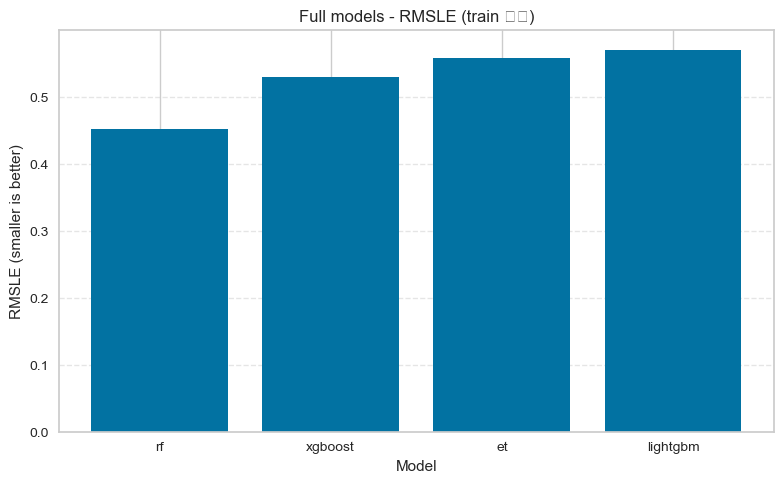

📁 그래프 저장 완료: ../images/full_models_rmsle_train.png


In [54]:
# %%
if full_metrics_df is not None:
    plt.figure(figsize=(8, 5))
    plt.bar(full_metrics_df["model"], full_metrics_df["RMSLE"])
    plt.title("Full models - RMSLE (train 기준)")
    plt.xlabel("Model")
    plt.ylabel("RMSLE (smaller is better)")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

    os.makedirs("../images", exist_ok=True)
    img_path = "../images/full_models_rmsle_train.png"
    plt.savefig(img_path, dpi=200)
    plt.show()

    print("📁 그래프 저장 완료:", img_path)


In [57]:
from pycaret.regression import load_model
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def compute_rmsle_from_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

In [58]:
from pycaret.regression import load_model

# metas는 이미 앞에서 만든 dict라고 가정
model_paths = {}
for model_name, info in metas.items():
    meta_path = info["meta_path"]  # 예: ../results/full_lgbm_20251209_210524_meta.json
    base = os.path.basename(meta_path).replace("_meta.json", "")  # full_lgbm_20251209_210524
    # PyCaret load_model에는 save_model 때 썼던 "확장자 없는 경로"를 그대로 넣으면 됨
    model_paths[model_name] = os.path.join("../models", base)

print(model_paths)
# 예시 출력:
# {'et': '../models/full_et_20251209_210815',
#  'lightgbm': '../models/full_lightgbm_20251209_210524',
#  'rf': '../models/full_rf_20251209_215256',
#  'xgboost': '../models/full_xgboost_20251209_210654'}

{'et': '../models\\full_et_20251209_210815', 'lightgbm': '../models\\full_lightgbm_20251209_210524', 'rf': '../models\\full_rf_20251209_215256', 'xgboost': '../models\\full_xgboost_20251209_210654'}


In [59]:
def get_full_model_preds(analyzer, model_paths):
    X = analyzer.train_vectorized
    y_log = analyzer.train["price"].values

    train_preds = {}
    for name, path_wo_ext in model_paths.items():
        model = load_model(path_wo_ext)   # "../models/full_lgbm_20251209_...."
        y_pred_log = model.predict(X)
        train_preds[name] = y_pred_log
    return y_log, train_preds

# model_paths 딕셔너리만 네 환경에 맞게 만들어놓고:
y_log, train_preds = get_full_model_preds(analyzer, model_paths)

# 예: 균등 voting
names = list(train_preds.keys())
stack = np.column_stack([train_preds[n] for n in names])
w = np.ones(len(names)) / len(names)
ens_log = stack @ w

rmsle_single = {n: compute_rmsle_from_log(y_log, train_preds[n]) for n in names}
rmsle_ens    = compute_rmsle_from_log(y_log, ens_log)

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
[LightGBM] [Warning] Unknown parameter: gpu
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


In [61]:
from pycaret.regression import load_model

def get_final_estimator(pipe):
    """
    PyCaret에서 load_model로 불러온 파이프라인에서
    실제 학습된 모델(estimator)을 최대한 안전하게 꺼내는 함수
    """
    # 1) named_steps가 있으면 우선 후보 키들부터 찾아보기
    if hasattr(pipe, "named_steps"):
        cand_keys = ["trained_model", "model", "regressor", "final_estimator"]
        for k in cand_keys:
            if k in pipe.named_steps:
                return pipe.named_steps[k]
        # 위 키들 다 없으면, 그냥 마지막 스텝을 estimator로 가정
        return list(pipe.named_steps.values())[-1]

    # 2) steps 속성이 있으면 마지막 스텝 사용
    if hasattr(pipe, "steps"):
        return pipe.steps[-1][1]

    # 3) 파이프 구조가 아니면, 이 객체 자체가 모델이라고 가정
    return pipe

In [65]:
from pycaret.regression import load_model
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1) 파이프라인 로드
pipe = load_model("../models/full_lightgbm_20251209_210524")
print("named_steps:", pipe.named_steps.keys())

# 2) 전처리 파트와 최종 모델 분리
preproc = pipe[:-1]                            # 마지막(estimator) 제외
lgbm = pipe.named_steps["actual_estimator"]    # ✅ 여기서 estimator 꺼냄
print("estimator type:", type(lgbm))

# 3) 전처리까지 거친 최종 feature 이름 얻기
X_sample = analyzer.train_vectorized.head(200)   # 샘플 몇 개만
X_transformed = preproc.transform(X_sample)

print("X_transformed type :", type(X_transformed))
print("X_transformed shape:", X_transformed.shape)

if hasattr(X_transformed, "columns"):
    feature_names = X_transformed.columns       # ✅ 전처리 후 컬럼
else:
    # 혹시 DataFrame이 아니면 배열 길이만큼 이름 자동 생성
    n_feats = len(lgbm.feature_importances_)
    feature_names = [f"f{i}" for i in range(n_feats)]

importances = lgbm.feature_importances_

print("len(feature_names):", len(feature_names))
print("len(importances)  :", len(importances))

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values("importance", ascending=False)
)
display(fi_df.head(30))


Transformation Pipeline and Model Successfully Loaded
named_steps: dict_keys(['numerical_imputer', 'categorical_imputer', 'ordinal_encoding', 'onehot_encoding', 'rest_encoding', 'normalize', 'actual_estimator'])
estimator type: <class 'lightgbm.sklearn.LGBMRegressor'>
X_transformed type : <class 'pandas.core.frame.DataFrame'>
X_transformed shape: (200, 215)
len(feature_names): 215
len(importances)  : 215


,feature,importance
212,sub_sub_cat,279
211,sub_cat,263
213,brand_name,222
200,main_cat_1.0,56
110,item_description_10,54
0,name_0,51
129,item_description_29,50
1,name_1,42
206,main_cat_0.0,37
103,item_description_3,37


,group,importance
4,name_svd,1120
2,desc_svd,860
1,category_raw,542
3,main_cat_onehot,223
0,brand,222
5,shipping,33


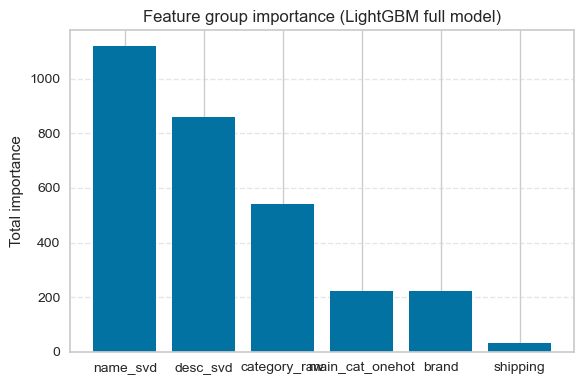

In [68]:
def aggregate_importance_by_group(fi_df):
    def _group(feat):
        if feat.startswith("name_"):
            return "name_svd"
        elif feat.startswith("item_description_"):
            return "desc_svd"
        elif feat.startswith("main_cat_"):
            return "main_cat_onehot"
        elif feat in ["main_cat", "sub_cat", "sub_sub_cat"]:
            return "category_raw"
        elif "brand_name" in feat:
            return "brand"
        elif "shipping" in feat:
            return "shipping"
        else:
            return "others"

    agg_df = (
        fi_df.assign(group=lambda d: d["feature"].map(_group))
             .groupby("group", as_index=False)["importance"].sum()
             .sort_values("importance", ascending=False)
    )
    return agg_df

agg_df = aggregate_importance_by_group(fi_df)
display(agg_df)

plt.figure(figsize=(6, 4))
plt.bar(agg_df["group"], agg_df["importance"])
plt.title("Feature group importance (LightGBM full model)")
plt.ylabel("Total importance")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

os.makedirs("../images", exist_ok=True)
plt.savefig("../images/lightgbm_feature_group_importance.png", dpi=200)
plt.show()